# 03_2b — Đối chiếu hình học mặt trời của 03_2 (bản v5 = pvlib) với hai kịch bản tham chiếu

**Mục đích (bản v5):** notebook 03_2 của v5 đã tính hình học mặt trời bằng **pvlib SPA + múi giờ
Australia/Melbourne thật (DST đổi đúng ngày)**. Notebook này kiểm chứng hai điều:

1. **Tái lập chính xác:** feature của 03_2 phải TRÙNG với pvlib tính lại ở múi giờ thật (tầng 2)
   — sai khác kỳ vọng ≈ 0.
2. **Cái giá của quy ước cũ:** nếu vẫn dùng phép gần đúng "DST cắt theo tháng" (hè 11/đông 10 —
   quy ước của v4), góc mặt trời lệch bao nhiêu (tầng 1) — đây là bằng chứng định lượng cho
   quyết định nâng cấp sang pvlib ở v5.

**Nguyên tắc:** chỉ ĐỌC output của 03_2, không ghi đè artifact pipeline; chạy sau 03_2,
ngoài chuỗi chính 00→08. Cần `pip install pvlib` (đã ghi trong requirements.txt).

In [2]:
import os
import numpy as np
import pandas as pd

try:
    import pvlib
    from pvlib import solarposition, clearsky
except ImportError as e:
    raise ImportError(
        "Thieu pvlib. Cai mot lan bang:  pip install pvlib\n"
        "(chi phuc vu notebook doi chieu nay, khong phai dependency cua pipeline)"
    ) from e

VERSION = 'v5'
INPUT_PATH = f'../../data/model/{VERSION}/03_2_features_spatial/{VERSION}_train_spatial.parquet'
OUTPUT_DIR = f'../../data/model/{VERSION}/03_2b_doi_chieu_pvlib'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
SO_DONG_MOI_TRAM = 2000          # ~2.000 moc/tram x 42 tram ~ 84k diem doi chieu
TZ_HE, TZ_DONG = 11.0, 10.0      # dung Y HET quy uoc cua 03_2

cot = ['site_id', 'timestamp', 'latitude', 'longitude',
       'solar_elevation', 'solar_azimuth', 'sin_elevation']
df = pd.read_parquet(INPUT_PATH, columns=cot)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Lay mau deu theo tram: xao mot lan roi lay N dong dau moi tram.
# KHONG dung groupby().apply(sample) vi pandas >= 2.2 loai cot group (site_id)
# khoi ket qua apply -> mat cot ngay tai day.
mau = (df.sample(frac=1.0, random_state=SEED)
         .groupby('site_id', observed=True)
         .head(SO_DONG_MOI_TRAM)
         .sort_values(['site_id', 'timestamp'])
         .reset_index(drop=True))
print(f"pvlib {pvlib.__version__} | doi chieu {len(mau):,} diem / {mau['site_id'].nunique()} tram")
print(f"Nguon: {INPUT_PATH}")

pvlib 0.15.2 | doi chieu 84,000 diem / 42 tram
Nguon: ../../data/model/v5/03_2_features_spatial/v5_train_spatial.parquet


In [3]:
# ── Tang 1: pvlib SPA voi CUNG quy uoc mui gio thang cua pipeline ──
# Pipeline coi timestamp la gio dia phuong voi offset co dinh theo thang (10/11h).
# Quy ve UTC bang dung offset do roi dua vao pvlib -> chenh lech con lai la
# khac biet THUAT TOAN thuan tuy (NOAA gian luoc vs SPA).
thang = mau['timestamp'].dt.month
tz_gio = np.where(thang.isin([10, 11, 12, 1, 2, 3]), TZ_HE, TZ_DONG)
utc_quy_uoc = (mau['timestamp'] - pd.to_timedelta(tz_gio, unit='h')).dt.tz_localize('UTC')

# ── Tang 2: mui gio Australia/Melbourne THAT (DST doi dung ngay) ──
# Cac moc roi vao gio khong ton tai / lap lai quanh thoi diem chuyen DST -> NaT, bo qua
# va DEM lai de biet pham vi anh huong.
melb = mau['timestamp'].dt.tz_localize('Australia/Melbourne',
                                       ambiguous='NaT', nonexistent='NaT')
utc_that = melb.dt.tz_convert('UTC')
n_nat = int(utc_that.isna().sum())

def goc_pvlib(utc_index, khung):
    ket = pd.DataFrame(index=khung.index, columns=['elevation', 'azimuth'], dtype=float)
    for (lat, lon), g in khung.groupby(['latitude', 'longitude']):
        idx = pd.DatetimeIndex(utc_index.loc[g.index])
        m = ~idx.isna()
        if m.sum() == 0:
            continue
        sp = solarposition.get_solarposition(idx[m], latitude=lat, longitude=lon)
        ket.loc[g.index[m], 'elevation'] = sp['elevation'].to_numpy()
        ket.loc[g.index[m], 'azimuth'] = sp['azimuth'].to_numpy()
    return ket

sp1 = goc_pvlib(utc_quy_uoc, mau)   # tang 1
sp2 = goc_pvlib(utc_that, mau)      # tang 2
print(f"Da tinh pvlib cho 2 tang. Moc NaT do chuyen DST (tang 2): {n_nat} diem (bo qua).")

Da tinh pvlib cho 2 tang. Moc NaT do chuyen DST (tang 2): 19 diem (bo qua).


In [4]:
# ── Sai so: elevation (do) va azimuth (do, co xu ly quan vong 0/360) ──
def sai_so_goc(a, b):
    d = np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))
    return np.minimum(d, 360.0 - d)

def bao_cao(ten, tay_el, pv_el, tay_az, pv_az, chi_ban_ngay):
    m = np.isfinite(np.asarray(pv_el, dtype=float))
    if chi_ban_ngay is not None:
        m = m & chi_ban_ngay
    de = np.abs(np.asarray(tay_el, dtype=float)[m] - np.asarray(pv_el, dtype=float)[m])
    da = sai_so_goc(np.asarray(tay_az, dtype=float)[m], np.asarray(pv_az, dtype=float)[m])
    dong = {
        'pham_vi': ten, 'n_diem': int(m.sum()),
        'elev_p50': np.percentile(de, 50), 'elev_p95': np.percentile(de, 95),
        'elev_p99': np.percentile(de, 99), 'elev_max': de.max(),
        'azim_p50': np.percentile(da, 50), 'azim_p95': np.percentile(da, 95),
        'azim_p99': np.percentile(da, 99), 'azim_max': da.max(),
    }
    return dong

ban_ngay = (mau['sin_elevation'].to_numpy() > 0.05)
rows = [
    bao_cao('T1 thuat_toan | moi diem',  mau['solar_elevation'], sp1['elevation'],
            mau['solar_azimuth'], sp1['azimuth'], None),
    bao_cao('T1 thuat_toan | ban ngay',  mau['solar_elevation'], sp1['elevation'],
            mau['solar_azimuth'], sp1['azimuth'], ban_ngay),
    bao_cao('T2 tz_that   | moi diem',   mau['solar_elevation'], sp2['elevation'],
            mau['solar_azimuth'], sp2['azimuth'], None),
    bao_cao('T2 tz_that   | ban ngay',   mau['solar_elevation'], sp2['elevation'],
            mau['solar_azimuth'], sp2['azimuth'], ban_ngay),
]
bang = pd.DataFrame(rows).round(4)
print("--- SAI SO SO VOI PVLIB (don vi: DO) ---")
print(bang.to_string(index=False))

# ── Haurwitz: cong thuc tay vs pvlib.clearsky.haurwitz tren CUNG goc cao pvlib tang 1 ──
# (tach rieng sai so cong thuc khoi sai so goc; pvlib haurwitz nhan apparent_zenith)
_el1 = np.asarray(sp1['elevation'], dtype=float)
_m = np.isfinite(_el1) & (_el1 > 0)
se = np.sin(np.radians(_el1[_m]))
ghi_tay = 1098.0 * se * np.exp(-0.059 / np.clip(se, 1e-3, None))
ghi_pv = clearsky.haurwitz(pd.Series(90.0 - _el1[_m])).to_numpy().ravel()
d_ghi = np.abs(ghi_tay - ghi_pv)
print("\n--- HAURWITZ: cong thuc tay vs pvlib (cung goc cao, W/m2) ---")
print(f"p50 {np.percentile(d_ghi, 50):.4f} | p99 {np.percentile(d_ghi, 99):.4f} | max {d_ghi.max():.4f}")

--- SAI SO SO VOI PVLIB (don vi: DO) ---
                 pham_vi  n_diem  elev_p50  elev_p95  elev_p99  elev_max  azim_p50  azim_p95  azim_p99  azim_max
T1 thuat_toan | moi diem   82056       0.0       0.0    9.4601   12.4019       0.0       0.0   11.2276   28.8656
T1 thuat_toan | ban ngay   38902       0.0       0.0    8.5403   12.3542       0.0       0.0   11.6713   26.6711
 T2 tz_that   | moi diem   82041       0.0       0.0    0.0000    5.1530       0.0       0.0    0.0000   28.6783
 T2 tz_that   | ban ngay   38902       0.0       0.0    0.0000    0.0000       0.0       0.0    0.0000    0.0000

--- HAURWITZ: cong thuc tay vs pvlib (cung goc cao, W/m2) ---
p50 0.0000 | p99 0.0000 | max 0.0000


In [5]:
# ── Ket luan + luu bang chung ──
bang.to_csv(f'{OUTPUT_DIR}/sai_so_vs_pvlib.csv', index=False)

t1 = bang.loc[bang['pham_vi'].str.contains('T1') & bang['pham_vi'].str.contains('ban ngay')].iloc[0]
t2 = bang.loc[bang['pham_vi'].str.contains('T2') & bang['pham_vi'].str.contains('ban ngay')].iloc[0]
print("=" * 78)
print("KET LUAN DOI CHIEU (ban ngay, sin_elevation > 0.05) — ngu canh V5 (03_2 = pvlib):")
print(f"  1. TAI LAP: feature 03_2 vs pvlib o TZ THAT (tang 2): "
      f"elevation p99 {t2['elev_p99']:.4f} do, max {t2['elev_max']:.4f} do")
print(f"  2. GIA CUA QUY UOC THANG CU (tang 1 - xap xi DST cua v4): "
      f"elevation p99 {t1['elev_p99']:.4f} do, max {t1['elev_max']:.4f} do")
print(f"  3. Haurwitz: ban cai dat pipeline khop pvlib.clearsky.haurwitz (xem o tren).")
print()
print("Cach doc: (1) ~ 0 => 03_2 v5 tai lap DUNG pvlib SPA + DST that - dat muc tieu.")
print("(2) => neu con giu quy uoc thang cua v4, goc mat troi sai toi vai do vao nhung")
print("ngay lech DST - day la bang chung dinh luong cho viec nang cap sang pvlib o v5.")
print(f"\nDa luu: {OUTPUT_DIR}/sai_so_vs_pvlib.csv")

KET LUAN DOI CHIEU (ban ngay, sin_elevation > 0.05) — ngu canh V5 (03_2 = pvlib):
  1. TAI LAP: feature 03_2 vs pvlib o TZ THAT (tang 2): elevation p99 0.0000 do, max 0.0000 do
  2. GIA CUA QUY UOC THANG CU (tang 1 - xap xi DST cua v4): elevation p99 8.5403 do, max 12.3542 do
  3. Haurwitz: ban cai dat pipeline khop pvlib.clearsky.haurwitz (xem o tren).

Cach doc: (1) ~ 0 => 03_2 v5 tai lap DUNG pvlib SPA + DST that - dat muc tieu.
(2) => neu con giu quy uoc thang cua v4, goc mat troi sai toi vai do vao nhung
ngay lech DST - day la bang chung dinh luong cho viec nang cap sang pvlib o v5.

Da luu: ../../data/model/v5/03_2b_doi_chieu_pvlib/sai_so_vs_pvlib.csv


## Kiểm tra trực quan: "ban ngày" có đúng ban ngày không?

Hai định nghĩa đang tồn tại trong pipeline:
1. **`is_daylight`** (notebook 01, gốc `weather_is_day` của Open-Meteo) — dùng để dán nhãn/chấm điểm
2. **`sin_elevation > 0.05`** (notebook 06) — cổng chọn dòng vào train và luật ép 0 khi dự báo

Vẽ chồng cả hai lên đường sản lượng THẬT của một ngày mùa hè và một ngày mùa đông,
kèm mốc 18:30 (quy ước cũ từng gây mất điện tối mùa hè ở tầng load — đã fix).
Thước đo: % kWh thật nằm NGOÀI mỗi vùng ban ngày — càng gần 0 càng đúng.

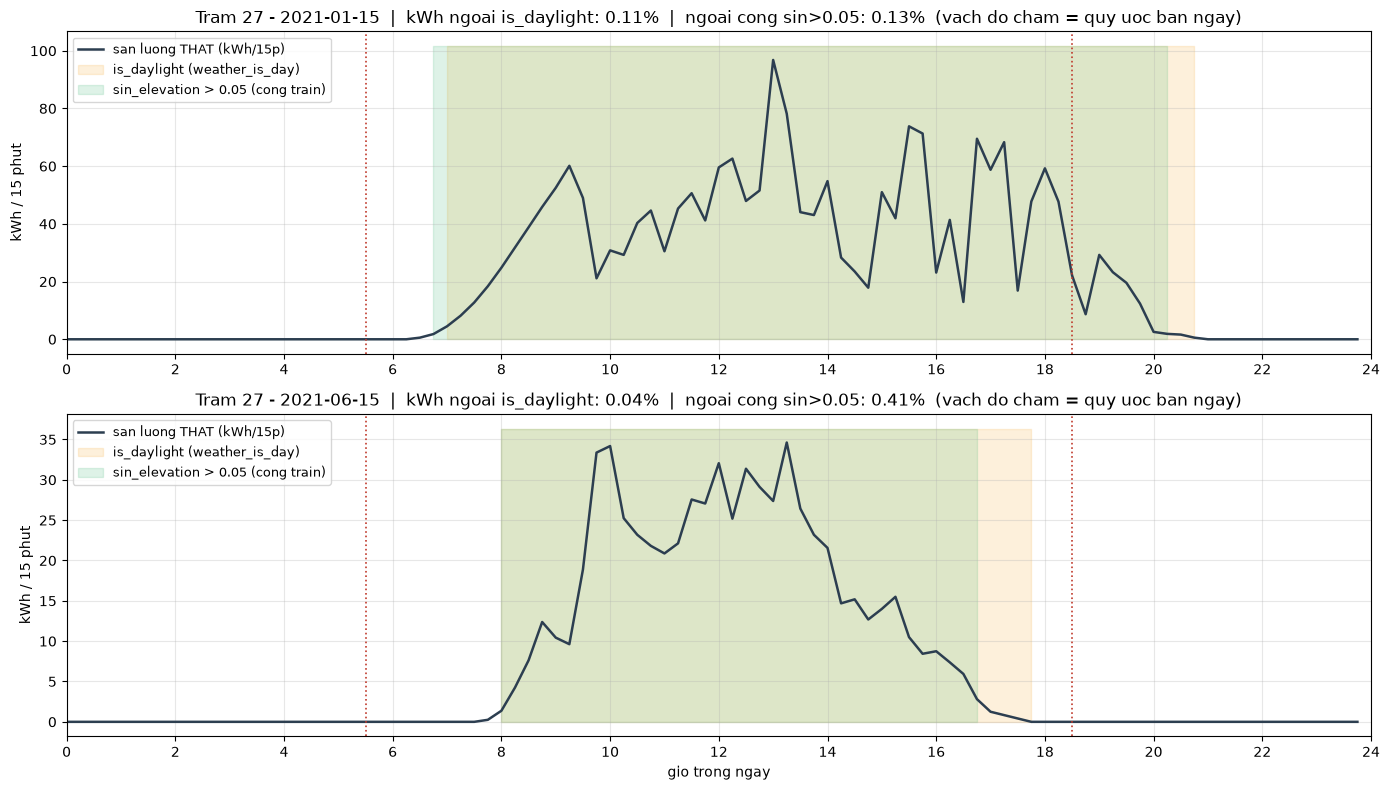

TOAN TAP TRAIN (do that): kWh ngoai is_daylight = 0.0505% | ngoai cong sin>0.05 = 0.0810%
Da luu ../../data/model/v5/03_2b_doi_chieu_pvlib/kiem_tra_ban_ngay.png


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_SEL = '../../data/model/v5/05_selected/v5_train_selected.parquet'
_d = pd.read_parquet(_SEL, columns=['site_id', 'timestamp', 'energy_generated_kwh',
                                    'energy_source', 'is_daylight', 'sin_elevation'])
_d['timestamp'] = pd.to_datetime(_d['timestamp'])
_SITE = 27
_NGAY = ['2021-01-15', '2021-06-15']   # he Uc / dong Uc, cung nam trong tap train

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for _ax, _ng in zip(axes, _NGAY):
    _z = _d[(_d['site_id'] == _SITE) & (_d['timestamp'].dt.date == pd.Timestamp(_ng).date())]
    _z = _z.sort_values('timestamp')
    _gio = _z['timestamp'].dt.hour + _z['timestamp'].dt.minute / 60
    _ax.plot(_gio, _z['energy_generated_kwh'], lw=1.8, color='#2c3e50', label='san luong THAT (kWh/15p)')
    _m1 = _z['is_daylight'].fillna(False).astype(bool).to_numpy()
    _m2 = (_z['sin_elevation'] > 0.05).to_numpy()
    _ax.fill_between(_gio, 0, _z['energy_generated_kwh'].max() * 1.05, where=_m1,
                     alpha=0.15, color='#f39c12', label='is_daylight (weather_is_day)')
    _ax.fill_between(_gio, 0, _z['energy_generated_kwh'].max() * 1.05, where=_m2,
                     alpha=0.15, color='#27ae60', label='sin_elevation > 0.05 (cong train)')
    for _v in (5.5, 18.5):
        _ax.axvline(_v, color='#c0392b', ls=':', lw=1.2)
    _e = _z['energy_generated_kwh'].to_numpy()
    _sot1 = _e[~_m1].sum() / max(_e.sum(), 1e-9) * 100
    _sot2 = _e[~_m2].sum() / max(_e.sum(), 1e-9) * 100
    _ax.set_title(f"Tram {_SITE} - {_ng}  |  kWh ngoai is_daylight: {_sot1:.2f}%  |  "
                  f"ngoai cong sin>0.05: {_sot2:.2f}%  (vach do cham = quy uoc ban ngay)")
    _ax.set_xlim(0, 24); _ax.set_xticks(range(0, 25, 2))
    _ax.set_ylabel('kWh / 15 phut'); _ax.grid(alpha=0.3); _ax.legend(fontsize=9, loc='upper left')
axes[1].set_xlabel('gio trong ngay')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/kiem_tra_ban_ngay.png', dpi=130)
plt.show()

# Thuoc do toan cuc tren ca tap train (do that): % kWh bi tung dinh nghia bo sot
_do = _d[_d['energy_source'].astype(str).eq('measured')]
_tong = _do['energy_generated_kwh'].sum()
_s1 = _do.loc[~_do['is_daylight'].fillna(False).astype(bool), 'energy_generated_kwh'].sum()
_s2 = _do.loc[~(_do['sin_elevation'] > 0.05), 'energy_generated_kwh'].sum()
print(f'TOAN TAP TRAIN (do that): kWh ngoai is_daylight = {_s1/_tong*100:.4f}% | '
      f'ngoai cong sin>0.05 = {_s2/_tong*100:.4f}%')
print(f"Da luu {OUTPUT_DIR}/kiem_tra_ban_ngay.png")

## Vì sao phải CẮT vùng rìa (0 < sin_elevation ≤ 0.05)?

Hình trên cho thấy cái giá của việc cắt (~0,08% kWh toàn tập train). Cell dưới trả lời
câu hỏi ngược lại — **nếu KHÔNG cắt thì mất gì** — bằng 3 con số đo trên chính tập train:

1. **Nhãn học nổ**: nhãn chuẩn hóa `k = y / (site_scale × sin_elevation)` có mẫu số tiến
   về 0 ở vùng rìa → cùng một lượng điện nhỏ lúc bình minh cho ra k khổng lồ, mô hình sẽ
   học nhãn nhiễu thay vì quy luật.
2. **Trần CLIP_K bị kéo méo**: trần cắt nhãn là q99 của k trên train — nếu tính cả vùng
   rìa, q99 bị chính các k-nổ kéo lên, làm sai thang chuẩn hóa cho TOÀN BỘ dòng bên trong.
3. **Đổi lại được rất ít**: lượng điện thật nằm trong vùng rìa không đáng kể (đo ở cell trên).

Đây chính là phương pháp "phân tích ngưỡng bằng hậu quả đo được" mà các paper trong
`.tex` dùng (xem 05b mục 17).

--- k_raw theo bin sin_elevation (dong measured, k tren dong co dien) ---
                 n_dong    kwh_%   k_p50    k_p99       k_max  %vuot_tran
sin_elevation                                                            
(0.0, 0.02]      2416.0   0.0169  0.9733  25.8183  19572.9159     25.5381
(0.02, 0.05]     6358.0   0.0559  0.4062   1.9704     16.0416      1.6672
(0.05, 0.1]     20559.0   0.2503  0.2876   1.4792      5.2804      0.5594
(0.1, 0.2]      55561.0   1.3887  0.3128   1.5198      5.1540      0.7163
(0.2, 0.4]     133951.0   9.9613  0.5040   2.2468      4.6185      1.5573
(0.4, 0.7]     253627.0  44.2888  0.8030   1.8549      2.4994      1.4659
(0.7, 1.0]     167931.0  44.0381  0.8688   1.3175      1.4416      0.0000

Vung ria (0 < sin <= 0.05): 8,774 dong, 3,006 kWh (0.0728% tong)
Tran q99 CHI trong cong sin>0.05 : 1.7108  (dung nhu 06 dang lam)
Tran q99 neu tinh CA vung ria    : 1.7608  (lech +2.92% -> thang chuan hoa bi keo meo)


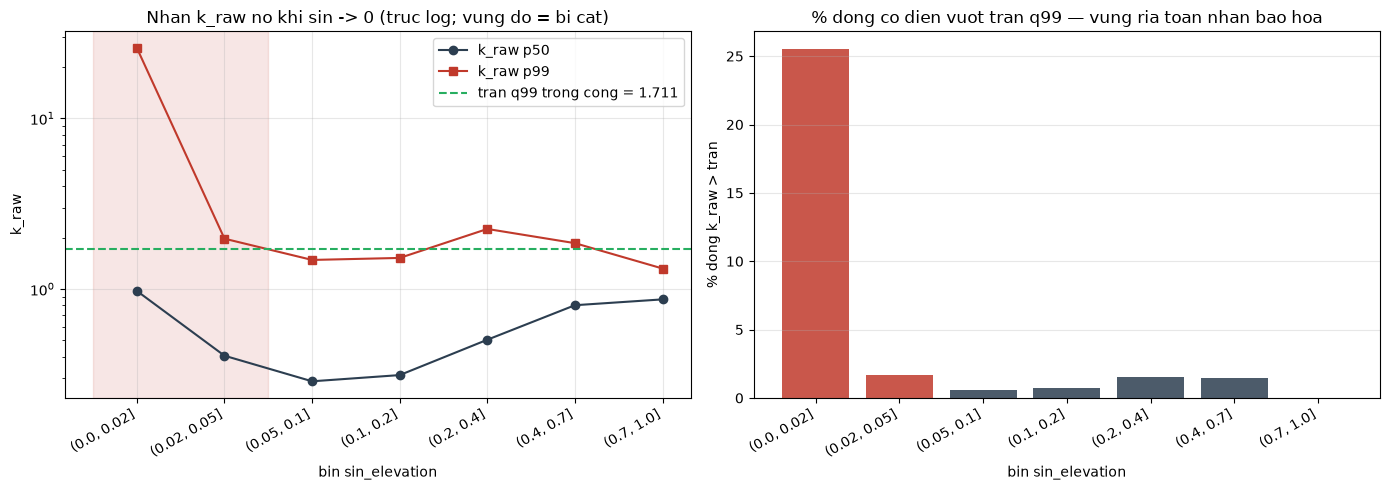

Da luu ../../data/model/v5/03_2b_doi_chieu_pvlib/vi_sao_cat_ria.png


In [7]:
# ── Bang chung vi sao cat vung ria: nhan k no khi sin -> 0 ──
_SEL = '../../data/model/v5/05_selected/v5_train_selected.parquet'
_f = pd.read_parquet(_SEL, columns=['energy_generated_kwh', 'sin_elevation',
                                    'site_scale', 'energy_source'])
_f = _f[(_f['energy_source'] == 'measured') & (_f['sin_elevation'] > 0)
        & (_f['site_scale'] > 0)].copy()
_f['k_raw'] = _f['energy_generated_kwh'] / (_f['site_scale'] * _f['sin_elevation'])

# Tran tham chieu: q99 cua k tinh DUNG nhu 06 (chi dong trong cong sin > 0.05)
_trong = _f[_f['sin_elevation'] > 0.05]
_tran_dung = float(np.quantile(_trong.loc[_trong['energy_generated_kwh'] > 0, 'k_raw'], 0.99))
_tran_meo = float(np.quantile(_f.loc[_f['energy_generated_kwh'] > 0, 'k_raw'], 0.99))

_bin = pd.cut(_f['sin_elevation'], [0, 0.02, 0.05, 0.10, 0.20, 0.40, 0.70, 1.0])
_co_dien = _f['energy_generated_kwh'] > 0
_tk = _f.groupby(_bin, observed=True).apply(
    lambda g: pd.Series({
        'n_dong': len(g),
        'kwh_%': g['energy_generated_kwh'].sum() / _f['energy_generated_kwh'].sum() * 100,
        'k_p50': g.loc[g['energy_generated_kwh'] > 0, 'k_raw'].median(),
        'k_p99': g.loc[g['energy_generated_kwh'] > 0, 'k_raw'].quantile(0.99),
        'k_max': g['k_raw'].max(),
        '%vuot_tran': (g.loc[g['energy_generated_kwh'] > 0, 'k_raw'] > _tran_dung).mean() * 100,
    }), include_groups=False)
print("--- k_raw theo bin sin_elevation (dong measured, k tren dong co dien) ---")
print(_tk.round(4).to_string())

_ria = _f['sin_elevation'] <= 0.05
print(f"\nVung ria (0 < sin <= 0.05): {int(_ria.sum()):,} dong, "
      f"{_f.loc[_ria, 'energy_generated_kwh'].sum():,.0f} kWh "
      f"({_f.loc[_ria, 'energy_generated_kwh'].sum() / _f['energy_generated_kwh'].sum() * 100:.4f}% tong)")
print(f"Tran q99 CHI trong cong sin>0.05 : {_tran_dung:.4f}  (dung nhu 06 dang lam)")
print(f"Tran q99 neu tinh CA vung ria    : {_tran_meo:.4f}  "
      f"(lech {(_tran_meo / _tran_dung - 1) * 100:+.2f}% -> thang chuan hoa bi keo meo)")

fig, (_a1, _a2) = plt.subplots(1, 2, figsize=(14, 5))
_x = np.arange(len(_tk))
_a1.plot(_x, _tk['k_p50'], 'o-', color='#2c3e50', label='k_raw p50')
_a1.plot(_x, _tk['k_p99'], 's-', color='#c0392b', label='k_raw p99')
_a1.axhline(_tran_dung, color='#27ae60', ls='--', lw=1.5,
            label=f'tran q99 trong cong = {_tran_dung:.3f}')
_a1.axvspan(-0.5, 1.5, alpha=0.12, color='#c0392b')
_a1.set_yscale('log'); _a1.set_xticks(_x)
_a1.set_xticklabels([str(i) for i in _tk.index], rotation=30, ha='right')
_a1.set_title('Nhan k_raw no khi sin -> 0 (truc log; vung do = bi cat)')
_a1.set_xlabel('bin sin_elevation'); _a1.set_ylabel('k_raw'); _a1.legend(); _a1.grid(alpha=0.3)
_a2.bar(_x, _tk['%vuot_tran'], color=['#c0392b'] * 2 + ['#2c3e50'] * (len(_tk) - 2), alpha=0.85)
_a2.set_xticks(_x); _a2.set_xticklabels([str(i) for i in _tk.index], rotation=30, ha='right')
_a2.set_title('% dong co dien vuot tran q99 — vung ria toan nhan bao hoa')
_a2.set_xlabel('bin sin_elevation'); _a2.set_ylabel('% dong k_raw > tran'); _a2.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/vi_sao_cat_ria.png', dpi=110, bbox_inches='tight')
plt.show()
print(f"Da luu {OUTPUT_DIR}/vi_sao_cat_ria.png")
